# Generating Input for MODFLOW

This notebook shows how to convert hydraulic soil properties from `pedon` models into parameters that can be used in FloPy-based MODFLOW workflows.

The workflow is:
1. Build or load a soil hydraulic model in `pedon`.
2. Evaluate water retention and conductivity over a pressure-head range.
3. Fit a MODFLOW-oriented parameterization (here: `Panday`).
4. Create MODFLOW-USG / MODFLOW 6 package inputs.

## FloPy references
- Bakker, M., Post, V., Langevin, C. D., Hughes, J. D., White, J. T., Starn, J. J., & Fienen, M. N. (2016). *Scripting MODFLOW Model Development Using Python and FloPy*. Groundwater, 54(5), 733-739. https://doi.org/10.1111/gwat.12413/epdf
- Hughes, J. D., Langevin, C. D., Paulinski, S. R., Larsen, J. D., & Brakenhoff, D. (2024). *FloPy Workflows for Creating Structured and Unstructured MODFLOW Models*. Groundwater, 62, 124-139. https://doi.org/10.1111/gwat.13327

In [1]:
import flopy as fp
import numpy as np
import pandas as pd

import pedon as pe

## Converting soil models

Here we generate synthetic retention and conductivity data from a `Genuchten` soil model and fit a `Panday` model to those data. This gives us a practical bridge from commonly available soil descriptions to parameters needed by MODFLOW packages.

This routine is described in more detail in the curve_fitting notebook.

(np.float64(0.0001), np.float64(1000000.0))

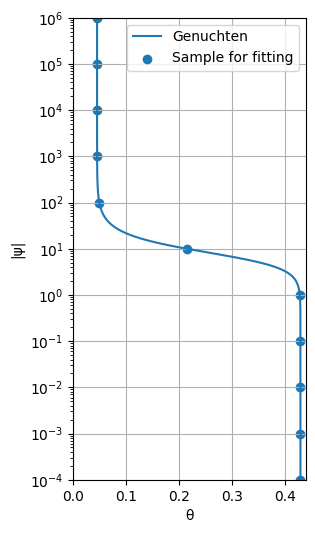

In [2]:
gen = pe.Soil("Sand").from_name(pe.Genuchten, source="HYDRUS").model
# gen = pe.Genuchten(k_s=100.0, theta_s=0.4, theta_r=0.05, alpha=0.1, n=2.0)

ax = gen.plot()

# sample the SWRC and HCF at 11 points between 10^-4 and 10^6 cm of pressure head
h = np.logspace(-4, 6, num=11)
theta = gen.theta(h)
k = gen.k(h)

ax.scatter(theta, h, color="C0", label="Sample for fitting")
ax.legend()
ax.set_ylim(h[0], h[-1])

### Fit SWRC and HCF
Normally, when fitting a soil model, we would fit both the soil water retention curve (SWRC) and the hydraulic conductivity function (HCF) simultaneously. This is because the parameters of these two functions are interrelated. However, in some cases, we might want to fit only the HCF, especially if we have more confidence in our retention data than in our conductivity data. In this example, we will fit both the SWRC and HCF simultaneously, and then we will fit only the HCF to see how it affects the resulting curve.

In [3]:
pbounds = pe.get_params(pe.Panday)
pbounds

pan_both = pe.SoilSample(theta=theta, k=k, h=h).fit(pe.Panday, pbounds=pbounds)
pan_both

Panday(k_s=np.float64(571.7082324246585), alpha=np.float64(0.14618016562833308), beta=np.float64(2.652658751825619), brook=np.float64(3.797937623049721), sr=np.float64(0.10452835579197751))

### Fit only the HCF

In [4]:
# Note that we set the bounds for theta_r, theta_s, alpha and n very small.
# This is because we want to fix these parameters during optimization and only
# optimize for the relative hydraulic conductivity curve with the brook parameter.

eps = 1e-10
pbounds_brook = pbounds.copy()
pbounds_brook.loc[["theta_r", "theta_s", "alpha", "beta"], :] = pd.DataFrame(
    {
        "p_ini": [gen.theta_r, gen.theta_s, gen.alpha, gen.n],
        "p_min": [gen.theta_r - eps, gen.theta_s - eps, gen.alpha - eps, gen.n - eps],
        "p_max": [gen.theta_r + eps, gen.theta_s + eps, gen.alpha + eps, gen.n + eps],
    },
    index=["theta_r", "theta_s", "alpha", "beta"],
)

pan = pe.SoilSample(h=h, theta=theta, k=k).fit(
    pe.Panday,
    pbounds=pbounds_brook,
    k_s=gen.k_s,  # fit relative hydraulic conductivity curve
)
pan

Panday(k_s=np.float64(712.8), alpha=np.float64(0.14500000009999997), beta=np.float64(2.679999999904514), brook=np.float64(3.7548440249344366), sr=np.float64(0.10465116278938343))

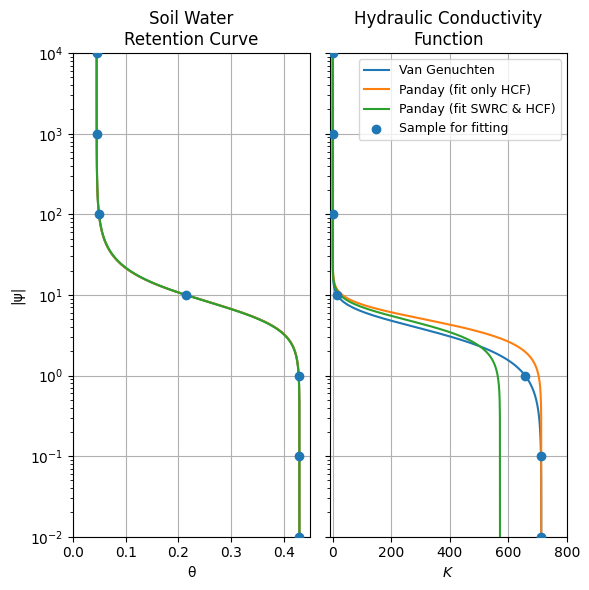

In [5]:
axes = pe.plot.curves(gen, label="Van Genuchten")
axes = pe.plot.curves(pan, axes=axes, label="Panday (fit only HCF)")
axes = pe.plot.curves(pan_both, axes=axes, label="Panday (fit SWRC & HCF)")
axes[0].scatter(theta, h, color="C0", label="Sample for fitting", zorder=10)
axes[1].scatter(k, h, color="C0", label="Sample for fitting", zorder=10)
axes[0].set_ylim(1e-2, 1e4)
axes[0].set_xlim(0.0, 0.45)
axes[0].set_title("Soil Water\nRetention Curve")
axes[1].set_ylabel("")
axes[1].set_xscale("linear")
axes[1].set_xlim(-10.0, 800.0)
axes[1].set_title("Hydraulic Conductivity\nFunction")
axes[1].legend(fontsize=9)

From this we can see that fitting only the HCF curve follows the original van Genuchten curve more closely than fitting both the SWRC and HCF simultaneously. When we fit both curves simultaneously, the parameters are adjusted to fit both datasets, which can lead to a compromise that does not fit either dataset as well as fitting only one curve.

## MODFLOW-USG Transport Parameters

The fitted `Panday` object (`pan`) can be mapped directly to `MfUsgLpf` soil-related inputs. Please make sur that the units are consistent with your MODFLOW model. 

In [6]:
# This code does not work but shows you how to parse the parameters
# to the MODFLOW USG Tranport LPF package.
try:
    fp.mfusg.MfUsgLpf(
        ...,
        hk=pan.k_s / 100.0,  # convert from cm/day to m/day
        sy=pan.theta_s,
        ss=pan.ss,
        alpha=pan.alpha * 100,  # convert from 1/cm to 1/m
        beta=pan.beta,
        sr=pan.sr,
        brook=pan.brook,
    )
except AssertionError:
    pass

## MODFLOW 6 UZF

For MODFLOW 6 UZF (Unsaturated Zone Flow) package, we provide effective unsaturated-zone parameters through `packagedata` (for example `vks`, `thtr`, `thts`, and `eps`). Unlike full retention-curve formulations, UZF uses a reduced parameterization of unsaturated flow behavior.

In [7]:
# packagedata : [(ifno, cellid, landflag, ivertcon, surfdep, vks, thtr, thts, thti, eps, boundname)]
packagedata = [
    (
        ...,
        ...,
        ...,
        ...,
        ...,
        pan.k_s / 100.0,
        pan.theta_r,
        pan.theta_s,
        ...,
        pan.brook,
        ...,
    ),
]
try:
    fp.mf6.ModflowGwfuzf(
        ...,
        packagedata=packagedata,
    )
except AttributeError:
    pass

In MODFLOW 6, via the MODFLOW API it should be possible to update soil water retention curve iteratively during a simulation. This would allow for dynamic feedback between soil moisture conditions and flow behavior, for example under hysteresis conditions. The MODFLOW API is available via FloPy, but this would require more custom coding to achieve.